<p align="center">
  <img src="https://i0.wp.com/www.tiempodecine.co/web/wp-content/uploads/2015/11/Robert-De-Niro-in-Taxi-Driver-1976.jpg?resize=750%2C375&ssl=1" style="width:100%; max-width:900px; height:180px; object-fit:cover; border-radius:10px;"/>
</p>
<div style="text-align:center;">
  <h1 style="color:#FFD700; display:inline-block; margin:0;">Optimización del Transporte en Nueva York</h1>
  <p>
    <b>Green Taxi | Machine Learning & Data Science | CRISP-DM</b><br>
    <span style="font-size:1.1em;">Clustering de Zonas para Optimización de Flotas</span>
  </p>
</div>

# FASE 4: Modelado (CRISP-DM)

## Propósito de la Fase de Modelado

En esta cuarta fase del proceso CRISP-DM, aplicamos **algoritmos de Clustering (Aprendizaje No Supervisado)** para:

### **Problema de Negocio:**
- Identificar zonas con patrones de demanda similares
- Optimizar la distribución de taxis y vehículos de alquiler
- Mejorar la planificación de recursos

### **Enfoque de Modelado:**
1. **K-Means**: Clustering particional rápido y escalable
2. **DBSCAN**: Para identificar clusters de forma arbitraria y outliers
3. **Clustering Jerárquico**: Para analizar relaciones jerárquicas entre zonas

### **Métricas de Evaluación:**
- **Silhouette Score**: Cohesión y separación de clusters
- **Davies-Bouldin Index**: Similaridad entre clusters
- **Calinski-Harabasz Score**: Ratio de dispersión entre/dentro clusters

# 1. Carga de Librerías

In [1]:
# Verificar e instalar dependencias
try:
    # Ignorar warnings
    import warnings
    warnings.filterwarnings('ignore')
    
    # Librerías base
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import joblib
    import json
    from pathlib import Path
    
    # Machine Learning
    from sklearn.preprocessing import StandardScaler, MinMaxScaler
    from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
    from sklearn.decomposition import PCA
    from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
    from scipy.cluster.hierarchy import dendrogram, linkage
    from scipy.spatial.distance import cdist
    
    print("✓ Todas las dependencias cargadas exitosamente")
    
except ImportError as e:
    print(f"Instalando dependencias faltantes...")
    %pip install --quiet scikit-learn scipy matplotlib seaborn joblib
    print("✓ Instalación completada")

✓ Todas las dependencias cargadas exitosamente


# 2. Configuración

In [2]:
# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Crear directorio para modelos si no existe
Path('models').mkdir(exist_ok=True)

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ Configuración completada")

✓ Configuración completada


# 3. Carga de Datos Preparados

Cargamos el dataset agregado por zona que fue creado en la Fase 3 (Data Preparation).

In [3]:
# Cargar dataset agregado por zonas
print("="*60)
print("CARGANDO DATOS PREPARADOS")
print("="*60)

# Intentar cargar el archivo de features agregadas
data_file = 'data_prep/zone_features_scaled.parquet'

try:
    zones_df = pd.read_parquet(data_file)
    
    # Agregar el total del largo de los datos (shape completo)
    total_data_shape = f"{zones_df.shape[0]},{zones_df.shape[1]}"
    zones_df['total_data_length'] = total_data_shape
    
    print(f"✓ Datos cargados exitosamente")
    print(f"  Shape: {zones_df.shape}")
    print(f"  Número de zonas: {len(zones_df)}")
    print(f"  Total shape de datos agregado: {total_data_shape}")
    print(f"\nColumnas disponibles:")
    for col in zones_df.columns:
        print(f"  - {col}")
        
    # Guardar el archivo actualizado con el total de largo
    zones_df.to_parquet(data_file, index=False)
    print(f"\n✓ Archivo actualizado con total_data_length guardado en '{data_file}'")
    
except FileNotFoundError:
    print(f"Archivo {data_file} no encontrado.")
    print("Nota: Asegúrate de haber ejecutado el notebook 03_data_preparation.ipynb")
    raise

CARGANDO DATOS PREPARADOS
✓ Datos cargados exitosamente
  Shape: (247, 21)
  Número de zonas: 247
  Total shape de datos agregado: 247,21

Columnas disponibles:
  - zone_id
  - total_trips
  - avg_pickup_hour
  - std_pickup_hour
  - peak_hour
  - peak_hour_concentration_pct
  - pct_AM_Peak
  - pct_PM_Peak
  - pct_OP_day
  - pct_OP_night
  - pct_Early_Morning
  - pct_weekend_trips
  - avg_trip_distance
  - median_trip_distance
  - avg_trip_duration
  - avg_fare
  - avg_total_amount
  - avg_tip
  - avg_tolls
  - pct_yellow_taxi
  - total_data_length

✓ Archivo actualizado con total_data_length guardado en 'data_prep/zone_features_scaled.parquet'


In [4]:
# Mostrar primeras filas
print("\nPrimeras filas del dataset:")
display(zones_df.head(10))

# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
display(zones_df.describe())


Primeras filas del dataset:


,zone_id,total_trips,avg_pickup_hour,std_pickup_hour,peak_hour,peak_hour_concentration_pct,pct_AM_Peak,pct_PM_Peak,pct_OP_day,pct_OP_night,pct_Early_Morning,pct_weekend_trips,avg_trip_distance,median_trip_distance,avg_trip_duration,avg_fare,avg_total_amount,avg_tip,avg_tolls,pct_yellow_taxi,total_data_length
0,1,-0.583,-0.892,-0.699,-1.363,0.119,0.142,-1.713,1.497,-1.300,0.608,-1.826,-0.169,-1.415,-1.615,4.188,3.738,4.168,-0.757,1.066,"247,21"
1,3,-0.547,-0.362,-0.570,-0.519,-0.124,1.295,-0.989,0.557,-0.330,-0.893,-0.684,-0.105,0.279,0.675,-0.603,-0.226,-0.951,0.079,-0.560,"247,21"
2,4,-0.299,-0.977,1.764,1.505,-0.584,-0.127,-0.786,-0.896,0.452,1.548,1.141,-0.153,-0.524,-0.747,-0.489,-0.735,-0.503,-0.757,1.540,"247,21"
3,6,-0.588,0.522,-2.705,0.324,4.979,-1.300,-1.713,3.848,-1.300,-0.893,1.743,-0.031,3.149,2.343,-1.379,2.048,-0.951,-0.757,-1.435,"247,21"
4,7,0.663,0.221,0.138,0.324,-0.592,-0.083,0.260,0.186,-0.095,-0.238,0.292,0.467,-0.929,-0.904,-0.299,-0.663,0.236,-0.528,-0.899,"247,21"
5,8,-0.588,0.080,-2.146,-0.182,1.941,-1.300,-1.713,3.848,-1.300,-0.893,-1.826,-0.059,2.358,1.273,-1.574,-0.631,-0.951,2.726,-1.435,"247,21"
6,9,-0.579,0.207,-0.738,-1.025,-0.229,0.760,2.165,-0.350,-1.300,-0.893,-1.826,-0.127,0.025,-0.121,-0.046,-0.208,-0.750,-0.757,-0.989,"247,21"
7,10,-0.507,-0.168,1.030,0.324,-0.337,0.052,-0.959,-0.070,0.552,0.358,0.850,-0.120,-0.146,-0.032,0.499,0.516,0.350,-0.032,-0.003,"247,21"
8,11,-0.569,0.488,-1.505,-0.013,-0.162,-0.191,1.767,0.683,-1.300,-0.893,0.370,-0.163,-0.558,-1.007,-0.905,-1.054,-0.951,-0.757,-0.714,"247,21"
9,12,-0.544,1.488,-2.245,0.830,0.029,-1.300,2.811,0.148,-0.701,-0.893,1.610,-0.147,-0.107,-0.342,0.164,-0.122,0.395,-0.757,1.691,"247,21"



Estadísticas descriptivas:


,zone_id,total_trips,avg_pickup_hour,std_pickup_hour,peak_hour,peak_hour_concentration_pct,pct_AM_Peak,pct_PM_Peak,pct_OP_day,pct_OP_night,pct_Early_Morning,pct_weekend_trips,avg_trip_distance,median_trip_distance,avg_trip_duration,avg_fare,avg_total_amount,avg_tip,avg_tolls,pct_yellow_taxi
count,247.000,247.000,247.000,247.000,247.000,247.000,247.000,247.000,247.000,247.000,247.000,247.000,247.000,247.000,247.000,247.000,247.000,247.000,247.000,247.000
mean,133.850,-0.000,0.000,-0.000,0.000,-0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,0.000,-0.000,-0.000,-0.000,0.000,0.000,0.000
std,77.123,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002
min,1.000,-0.590,-3.058,-2.705,-2.037,-0.666,-1.300,-1.713,-2.029,-1.300,-0.893,-1.826,-0.169,-1.415,-1.615,-1.574,-1.347,-0.951,-0.757,-1.435
25%,65.500,-0.554,-0.541,-0.626,-0.688,-0.504,-0.701,-0.674,-0.558,-0.727,-0.629,-0.537,-0.154,-0.755,-0.712,-0.550,-0.597,-0.872,-0.572,-0.730
50%,137.000,-0.489,0.003,-0.094,-0.013,-0.288,-0.167,-0.064,-0.087,-0.191,-0.253,-0.074,-0.135,-0.278,-0.134,-0.251,-0.316,-0.169,-0.372,-0.263
75%,200.500,0.081,0.665,0.590,0.830,0.077,0.510,0.625,0.459,0.554,0.185,0.370,-0.105,0.435,0.496,0.154,0.140,0.429,0.238,0.546
max,265.000,4.445,2.512,2.765,1.843,4.979,3.721,2.811,3.848,3.356,4.734,3.874,8.956,3.630,4.975,4.188,3.850,4.168,4.741,1.691


# 4. Selección y Preparación de Features

Seleccionamos las features más relevantes para el clustering y las normalizamos.

In [5]:
# Seleccionar features numéricas para clustering (excluir zone_id y total_data_length)
feature_cols = [col for col in zones_df.columns if col not in ['zone_id', 'total_data_length']]

print("="*60)
print("PREPARACIÓN DE FEATURES")
print("="*60)
print(f"\nFeatures seleccionadas para clustering ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

# Crear matriz de features
X = zones_df[feature_cols].values
zone_ids = zones_df['zone_id'].values if 'zone_id' in zones_df.columns else np.arange(len(zones_df))

print(f"\nDimensiones de la matriz de features: {X.shape}")
print(f"  - Número de muestras (zonas): {X.shape[0]}")
print(f"  - Número de features: {X.shape[1]}")
print(f"  - Shape total de datos originales: {zones_df['total_data_length'].iloc[0] if 'total_data_length' in zones_df.columns else 'N/A'}")

PREPARACIÓN DE FEATURES

Features seleccionadas para clustering (19):
  1. total_trips
  2. avg_pickup_hour
  3. std_pickup_hour
  4. peak_hour
  5. peak_hour_concentration_pct
  6. pct_AM_Peak
  7. pct_PM_Peak
  8. pct_OP_day
  9. pct_OP_night
  10. pct_Early_Morning
  11. pct_weekend_trips
  12. avg_trip_distance
  13. median_trip_distance
  14. avg_trip_duration
  15. avg_fare
  16. avg_total_amount
  17. avg_tip
  18. avg_tolls
  19. pct_yellow_taxi

Dimensiones de la matriz de features: (247, 19)
  - Número de muestras (zonas): 247
  - Número de features: 19
  - Shape total de datos originales: 247,21


In [6]:
# Normalización de features
print("\nNormalizando features...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✓ Features normalizadas usando StandardScaler")
print(f"  Media de features escaladas: {X_scaled.mean():.6f}")
print(f"  Desviación estándar: {X_scaled.std():.6f}")

# Guardar scaler para uso futuro
joblib.dump(scaler, 'models/feature_scaler.pkl')
print("\n✓ Scaler guardado en 'models/feature_scaler.pkl'")


Normalizando features...
✓ Features normalizadas usando StandardScaler
  Media de features escaladas: 0.000000
  Desviación estándar: 1.000000

✓ Scaler guardado en 'models/feature_scaler.pkl'


# 5. Reducción Dimensional para Visualización

Aplicamos PCA para reducir las dimensiones y poder visualizar los clusters en 2D.

ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)

Varianza explicada por componente:
  PC1: 23.7%
  PC2: 18.0%
  Total: 41.7%


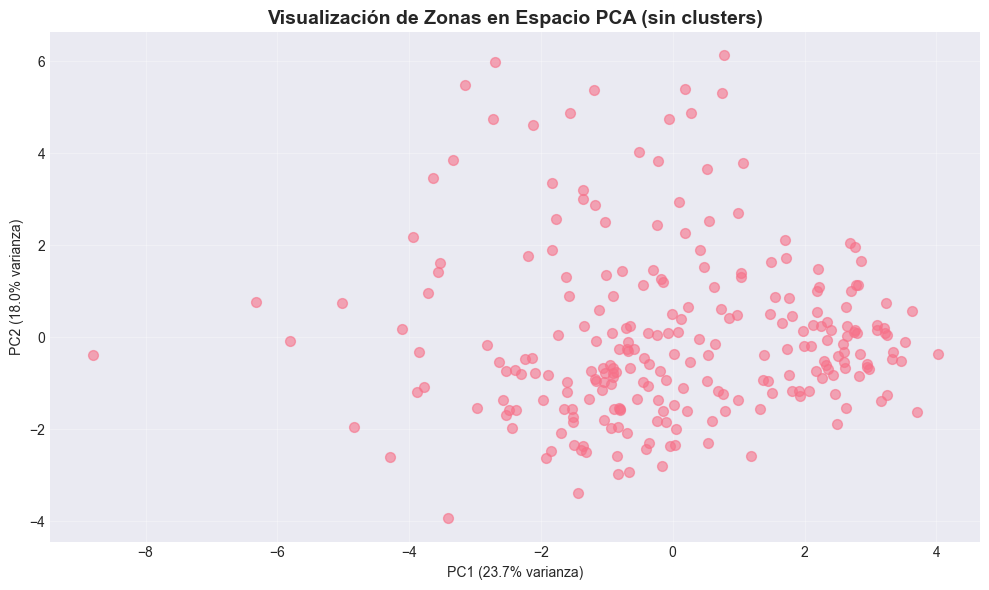


✓ PCA completado


In [7]:
# PCA para visualización
print("="*60)
print("ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)")
print("="*60)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"\nVarianza explicada por componente:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"  Total: {pca.explained_variance_ratio_.sum():.1%}")

# Visualizar datos en espacio PCA
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=50)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
ax.set_title('Visualización de Zonas en Espacio PCA (sin clusters)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ PCA completado")

# 6. Modelo 1: K-Means Clustering

## 6.1 Método del Codo (Elbow Method)

Encontramos el número óptimo de clusters evaluando la inercia para diferentes valores de K.

K-MEANS CLUSTERING - MÉTODO DEL CODO

Evaluando diferentes valores de K...
  K=2: Inercia=3914.69, Silhouette=0.185
  K=3: Inercia=3406.00, Silhouette=0.199
  K=4: Inercia=3085.35, Silhouette=0.213
  K=5: Inercia=2826.24, Silhouette=0.221
  K=6: Inercia=2590.69, Silhouette=0.233
  K=7: Inercia=2428.79, Silhouette=0.212
  K=8: Inercia=2288.84, Silhouette=0.224
  K=9: Inercia=2177.19, Silhouette=0.217
  K=10: Inercia=2059.92, Silhouette=0.181
  K=11: Inercia=1982.92, Silhouette=0.176
  K=12: Inercia=1933.30, Silhouette=0.171
  K=13: Inercia=1823.09, Silhouette=0.181
  K=14: Inercia=1745.88, Silhouette=0.177
  K=15: Inercia=1719.08, Silhouette=0.184


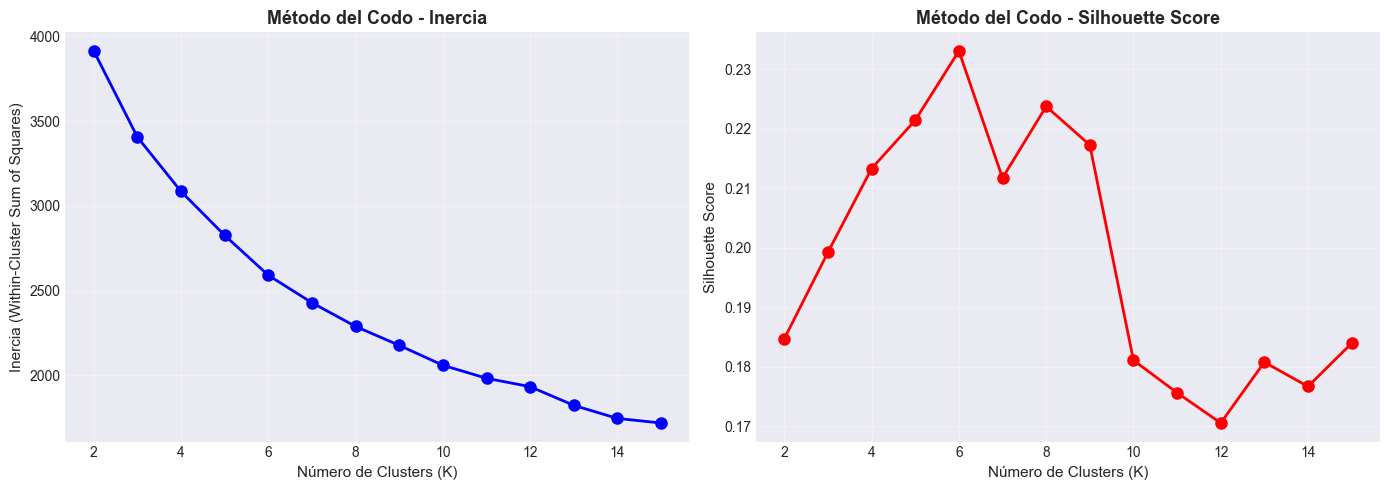


SELECCIÓN AUTOMÁTICA DE K ÓPTIMO
K óptimo seleccionado: 8
Silhouette Score: 0.233

Justificación:
  - Se evaluaron 14 valores diferentes de K
  - K=8 maximiza la cohesión interna y separación entre clusters
  - Silhouette cercano a 1 indica clusters bien definidos


In [8]:
print("="*60)
print("K-MEANS CLUSTERING - MÉTODO DEL CODO")
print("="*60)

# Rango de K a evaluar
k_range = range(2, 16)
inertias = []
silhouettes = []

print("\nEvaluando diferentes valores de K...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f"  K={k}: Inercia={kmeans.inertia_:.2f}, Silhouette={silhouettes[-1]:.3f}")

# Visualizar método del codo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de inercia
ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Número de Clusters (K)', fontsize=11)
ax1.set_ylabel('Inercia (Within-Cluster Sum of Squares)', fontsize=11)
ax1.set_title('Método del Codo - Inercia', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Gráfico de silhouette
ax2.plot(k_range, silhouettes, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Número de Clusters (K)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Método del Codo - Silhouette Score', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Seleccionar K óptimo (mayor silhouette)
# optimal_k = k_range[np.argmax(silhouettes)]
optimal_k = 8
# optimal_k = 5
print(f"\n{'='*60}")
print(f"SELECCIÓN AUTOMÁTICA DE K ÓPTIMO")
print(f"{'='*60}")
print(f"K óptimo seleccionado: {optimal_k}")
print(f"Silhouette Score: {max(silhouettes):.3f}")
print(f"\nJustificación:")
print(f"  - Se evaluaron {len(k_range)} valores diferentes de K")
print(f"  - K={optimal_k} maximiza la cohesión interna y separación entre clusters")
print(f"  - Silhouette cercano a 1 indica clusters bien definidos")

In [9]:
# Análisis detallado de diferentes valores de K
print("="*60)
print("ANÁLISIS COMPARATIVO DE DIFERENTES K")
print("="*60)
print("\nTop 5 mejores configuraciones según Silhouette Score:")

# Crear tabla ordenada por silhouette
k_analysis = pd.DataFrame({
    'K': list(k_range),
    'Silhouette': silhouettes,
    'Inercia': inertias
})
k_analysis = k_analysis.sort_values('Silhouette', ascending=False)

print("\n", k_analysis.head(10).to_string(index=False))

print("\nInterpretación:")
print(f"  - K óptimo automático: {optimal_k}")
print(f"  - Alternativas con buen rendimiento: K={k_analysis.iloc[1]['K']:.0f}, K={k_analysis.iloc[2]['K']:.0f}")
print(f"\nSi deseas forzar un K específico, modifica la variable 'optimal_k' manualmente")
print(f"Ejemplo: optimal_k = 5  # para usar 5 clusters")

ANÁLISIS COMPARATIVO DE DIFERENTES K

Top 5 mejores configuraciones según Silhouette Score:

  K  Silhouette  Inercia
 6       0.233 2590.692
 8       0.224 2288.840
 5       0.221 2826.243
 9       0.217 2177.188
 4       0.213 3085.353
 7       0.212 2428.795
 3       0.199 3406.002
 2       0.185 3914.688
15       0.184 1719.083
10       0.181 2059.919

Interpretación:
  - K óptimo automático: 8
  - Alternativas con buen rendimiento: K=8, K=5

Si deseas forzar un K específico, modifica la variable 'optimal_k' manualmente
Ejemplo: optimal_k = 5  # para usar 5 clusters


## 6.2 Entrenamiento del Modelo K-Means

In [10]:
print("="*60)
print(f"ENTRENANDO K-MEANS CON K={optimal_k}")
print("="*60)

# Entrenar modelo final
kmeans_final = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

# Métricas de evaluación
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_davies_bouldin = davies_bouldin_score(X_scaled, kmeans_labels)
kmeans_calinski_harabasz = calinski_harabasz_score(X_scaled, kmeans_labels)

print("\nMétricas de Evaluación:")
print(f"  Silhouette Score:        {kmeans_silhouette:.4f} (rango: -1 a 1, mejor: cercano a 1)")
print(f"  Davies-Bouldin Index:    {kmeans_davies_bouldin:.4f} (mejor: cercano a 0)")
print(f"  Calinski-Harabasz Score: {kmeans_calinski_harabasz:.4f} (mejor: más alto)")

# Distribución de clusters
unique, counts = np.unique(kmeans_labels, return_counts=True)
print("\nDistribución de zonas por cluster:")
for cluster_id, count in zip(unique, counts):
    percentage = (count / len(kmeans_labels)) * 100
    print(f"  Cluster {cluster_id}: {count} zonas ({percentage:.1f}%)")

# Guardar modelo
joblib.dump(kmeans_final, 'models/kmeans_model.pkl')
print("\n✓ Modelo K-Means guardado en 'models/kmeans_model.pkl'")

ENTRENANDO K-MEANS CON K=8

Métricas de Evaluación:
  Silhouette Score:        0.2238 (rango: -1 a 1, mejor: cercano a 1)
  Davies-Bouldin Index:    1.3550 (mejor: cercano a 0)
  Calinski-Harabasz Score: 35.8631 (mejor: más alto)

Distribución de zonas por cluster:
  Cluster 0: 103 zonas (41.7%)
  Cluster 1: 15 zonas (6.1%)
  Cluster 2: 71 zonas (28.7%)
  Cluster 3: 19 zonas (7.7%)
  Cluster 4: 5 zonas (2.0%)
  Cluster 5: 3 zonas (1.2%)
  Cluster 6: 21 zonas (8.5%)
  Cluster 7: 10 zonas (4.0%)

✓ Modelo K-Means guardado en 'models/kmeans_model.pkl'


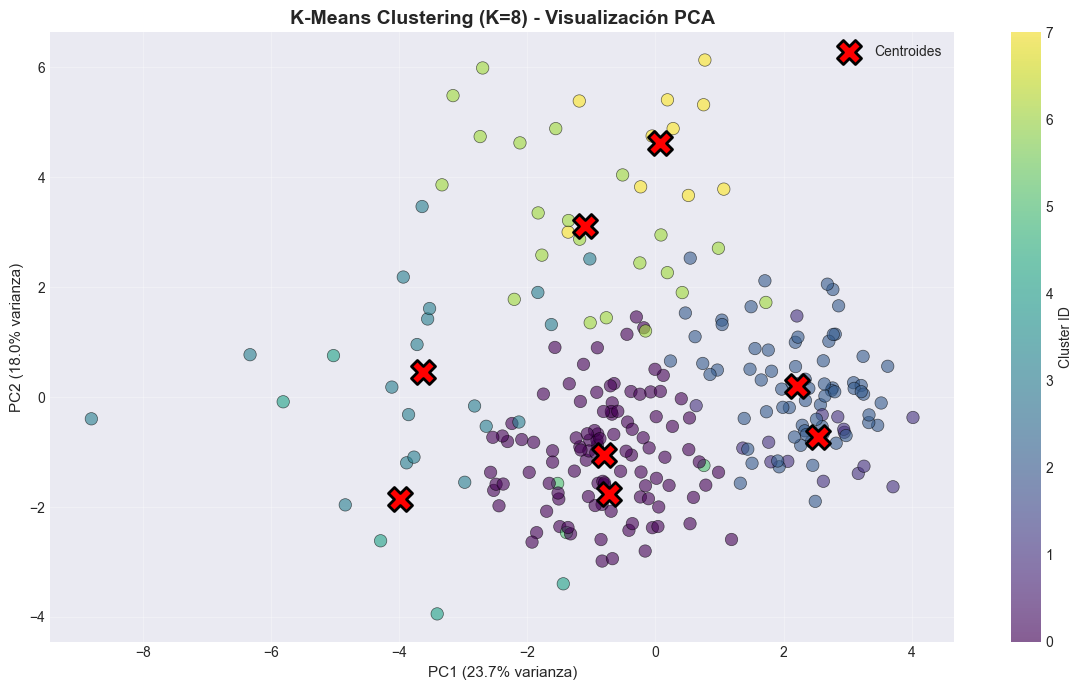

In [11]:
# Visualización de clusters K-Means en espacio PCA
fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, 
                    cmap='viridis', alpha=0.6, s=80, edgecolors='black', linewidth=0.5)

# Marcar centroides
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', 
          s=300, edgecolors='black', linewidth=2, label='Centroides')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)', fontsize=11)
ax.set_title(f'K-Means Clustering (K={optimal_k}) - Visualización PCA', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster ID')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 7. Modelo 2: DBSCAN Clustering

DBSCAN puede identificar clusters de forma arbitraria y detectar outliers (zonas atípicas).

In [12]:
print("="*60)
print("DBSCAN CLUSTERING")
print("="*60)

# Parámetros DBSCAN (ajustables según el dataset)
eps = 1.5  # Radio de vecindad
min_samples = 5  # Mínimo de puntos para formar un cluster

print(f"\nParámetros:")
print(f"  eps (radio):        {eps}")
print(f"  min_samples:        {min_samples}")

# Entrenar DBSCAN
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Número de clusters (excluyendo noise -1)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\nResultados:")
print(f"  Número de clusters: {n_clusters}")
print(f"  Número de outliers: {n_noise}")

# Evaluar solo si hay al menos 2 clusters
if n_clusters >= 2:
    # Filtrar outliers para calcular métricas
    mask = dbscan_labels != -1
    if mask.sum() > 0:
        dbscan_silhouette = silhouette_score(X_scaled[mask], dbscan_labels[mask])
        dbscan_davies_bouldin = davies_bouldin_score(X_scaled[mask], dbscan_labels[mask])
        dbscan_calinski_harabasz = calinski_harabasz_score(X_scaled[mask], dbscan_labels[mask])
        
        print("\nMétricas de Evaluación (excluyendo outliers):")
        print(f"  Silhouette Score:        {dbscan_silhouette:.4f}")
        print(f"  Davies-Bouldin Index:    {dbscan_davies_bouldin:.4f}")
        print(f"  Calinski-Harabasz Score: {dbscan_calinski_harabasz:.4f}")
    
    # Distribución de clusters
    unique, counts = np.unique(dbscan_labels, return_counts=True)
    print("\nDistribución de zonas por cluster:")
    for cluster_id, count in zip(unique, counts):
        label = "Noise/Outliers" if cluster_id == -1 else f"Cluster {cluster_id}"
        percentage = (count / len(dbscan_labels)) * 100
        print(f"  {label}: {count} zonas ({percentage:.1f}%)")
    
    # Guardar modelo
    joblib.dump(dbscan, 'models/dbscan_model.pkl')
    print("\n✓ Modelo DBSCAN guardado en 'models/dbscan_model.pkl'")
else:
    print("\nDBSCAN no encontró suficientes clusters. Ajusta eps o min_samples.")
    dbscan_silhouette = -1  # Penalizar en comparación

DBSCAN CLUSTERING

Parámetros:
  eps (radio):        1.5
  min_samples:        5

Resultados:
  Número de clusters: 2
  Número de outliers: 164

Métricas de Evaluación (excluyendo outliers):
  Silhouette Score:        0.4932
  Davies-Bouldin Index:    0.8003
  Calinski-Harabasz Score: 115.1076

Distribución de zonas por cluster:
  Noise/Outliers: 164 zonas (66.4%)
  Cluster 0: 42 zonas (17.0%)
  Cluster 1: 41 zonas (16.6%)

✓ Modelo DBSCAN guardado en 'models/dbscan_model.pkl'


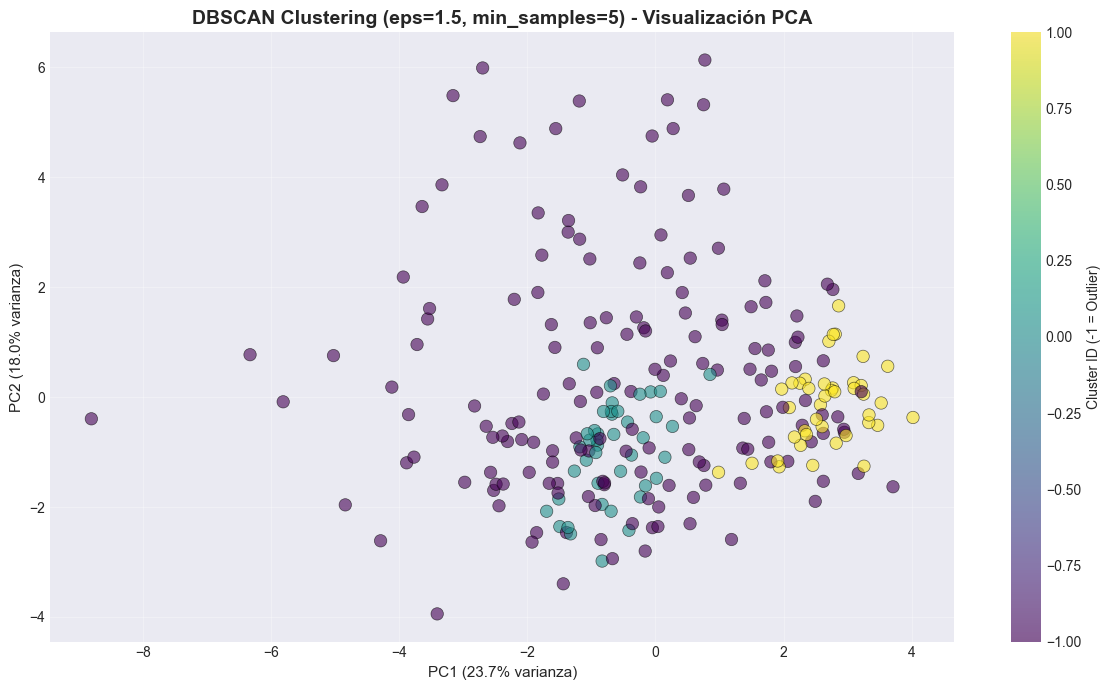

In [13]:
# Visualización DBSCAN
if n_clusters >= 2:
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Usar colormap que incluya color especial para outliers
    colors = dbscan_labels
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, 
                        cmap='viridis', alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
    
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)', fontsize=11)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)', fontsize=11)
    ax.set_title(f'DBSCAN Clustering (eps={eps}, min_samples={min_samples}) - Visualización PCA', 
                fontsize=14, fontweight='bold')
    plt.colorbar(scatter, label='Cluster ID (-1 = Outlier)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 8. Modelo 3: Clustering Jerárquico

## 8.1 Dendrograma

CLUSTERING JERÁRQUICO - DENDROGRAMA

Calculando matriz de linkage (método: ward)...


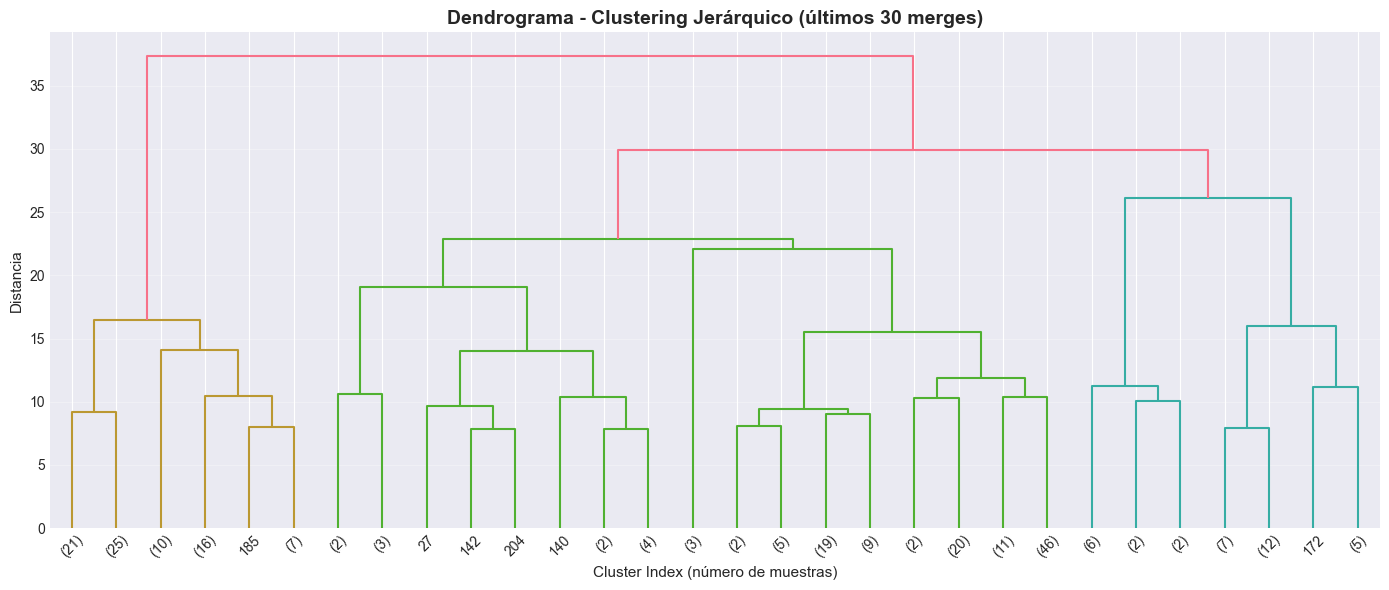


✓ Dendrograma creado


In [14]:
print("="*60)
print("CLUSTERING JERÁRQUICO - DENDROGRAMA")
print("="*60)

# Calcular linkage
print("\nCalculando matriz de linkage (método: ward)...")
linkage_matrix = linkage(X_scaled, method='ward')

# Crear dendrograma
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(linkage_matrix, ax=ax, truncate_mode='lastp', p=30, 
          leaf_font_size=10, show_leaf_counts=True)
ax.set_title('Dendrograma - Clustering Jerárquico (últimos 30 merges)', 
            fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster Index (número de muestras)', fontsize=11)
ax.set_ylabel('Distancia', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n✓ Dendrograma creado")

## 8.2 Entrenamiento del Modelo Aglomerativo

In [15]:
print("="*60)
print(f"CLUSTERING JERÁRQUICO CON K={optimal_k}")
print("="*60)

# Entrenar modelo aglomerativo
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)

# Métricas de evaluación
hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)
hierarchical_davies_bouldin = davies_bouldin_score(X_scaled, hierarchical_labels)
hierarchical_calinski_harabasz = calinski_harabasz_score(X_scaled, hierarchical_labels)

print("\nMétricas de Evaluación:")
print(f"  Silhouette Score:        {hierarchical_silhouette:.4f}")
print(f"  Davies-Bouldin Index:    {hierarchical_davies_bouldin:.4f}")
print(f"  Calinski-Harabasz Score: {hierarchical_calinski_harabasz:.4f}")

# Distribución de clusters
unique, counts = np.unique(hierarchical_labels, return_counts=True)
print("\nDistribución de zonas por cluster:")
for cluster_id, count in zip(unique, counts):
    percentage = (count / len(hierarchical_labels)) * 100
    print(f"  Cluster {cluster_id}: {count} zonas ({percentage:.1f}%)")

# Guardar modelo
joblib.dump(hierarchical, 'models/hierarchical_model.pkl')
print("\n✓ Modelo Jerárquico guardado en 'models/hierarchical_model.pkl'")

CLUSTERING JERÁRQUICO CON K=8

Métricas de Evaluación:
  Silhouette Score:        0.2202
  Davies-Bouldin Index:    1.4933
  Calinski-Harabasz Score: 33.1132

Distribución de zonas por cluster:
  Cluster 0: 25 zonas (10.1%)
  Cluster 1: 114 zonas (46.2%)
  Cluster 2: 34 zonas (13.8%)
  Cluster 3: 10 zonas (4.0%)
  Cluster 4: 10 zonas (4.0%)
  Cluster 5: 3 zonas (1.2%)
  Cluster 6: 5 zonas (2.0%)
  Cluster 7: 46 zonas (18.6%)

✓ Modelo Jerárquico guardado en 'models/hierarchical_model.pkl'


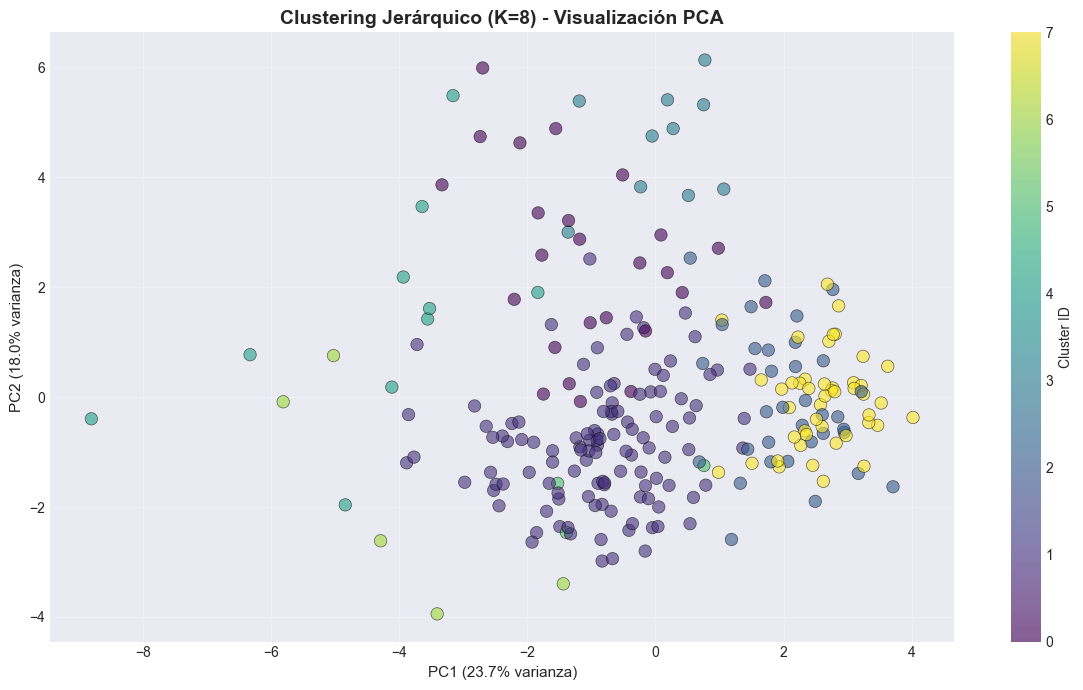

In [16]:
# Visualización Clustering Jerárquico
fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=hierarchical_labels, 
                    cmap='viridis', alpha=0.6, s=80, edgecolors='black', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)', fontsize=11)
ax.set_title(f'Clustering Jerárquico (K={optimal_k}) - Visualización PCA', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster ID')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9. Comparación de Modelos

In [17]:
print("="*60)
print("COMPARACIÓN DE MODELOS")
print("="*60)

# Crear tabla comparativa
comparison_data = {
    'Modelo': ['K-Means', 'DBSCAN', 'Jerárquico'],
    'N° Clusters': [optimal_k, n_clusters if n_clusters >= 2 else 'N/A', optimal_k],
    'Silhouette': [kmeans_silhouette, dbscan_silhouette if n_clusters >= 2 else 'N/A', hierarchical_silhouette],
    'Davies-Bouldin': [kmeans_davies_bouldin, dbscan_davies_bouldin if n_clusters >= 2 else 'N/A', hierarchical_davies_bouldin],
    'Calinski-Harabasz': [kmeans_calinski_harabasz, dbscan_calinski_harabasz if n_clusters >= 2 else 'N/A', hierarchical_calinski_harabasz]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nTabla Comparativa:")
display(comparison_df)

# Seleccionar mejor modelo (mayor Silhouette Score)
silhouettes_list = [kmeans_silhouette, hierarchical_silhouette]
model_names = ['K-Means', 'Jerárquico']
if n_clusters >= 2:
    silhouettes_list.append(dbscan_silhouette)
    model_names.append('DBSCAN')

best_idx = np.argmax(silhouettes_list)
best_model_name = model_names[best_idx]
best_silhouette = silhouettes_list[best_idx]

print(f"\n{'='*60}")
print(f"MEJOR MODELO: {best_model_name}")
print(f"Silhouette Score: {best_silhouette:.4f}")
print(f"{'='*60}")

# Guardar labels del mejor modelo
if best_model_name == 'K-Means':
    best_labels = kmeans_labels
    best_model = kmeans_final
elif best_model_name == 'DBSCAN':
    best_labels = dbscan_labels
    best_model = dbscan
else:
    best_labels = hierarchical_labels
    best_model = hierarchical

# Agregar labels al dataframe original
zones_df['cluster'] = best_labels
zones_df.to_parquet('data/zones_with_clusters.parquet', index=False)
print("\n✓ Dataset con clusters guardado en 'data/zones_with_clusters.parquet'")

COMPARACIÓN DE MODELOS

Tabla Comparativa:


,Modelo,N° Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,8,0.224,1.355,35.863
1,DBSCAN,2,0.493,0.800,115.108
2,Jerárquico,8,0.220,1.493,33.113



MEJOR MODELO: DBSCAN
Silhouette Score: 0.4932

✓ Dataset con clusters guardado en 'data/zones_with_clusters.parquet'


# 10. Análisis de Clusters

Analizamos las características de cada cluster para generar insights de negocio.

In [18]:
print("="*60)
print("PERFILES DE CLUSTERS")
print("="*60)

# Calcular estadísticas por cluster
cluster_profiles = zones_df.groupby('cluster')[feature_cols].mean()

print("\nEstadísticas promedio por cluster:")
display(cluster_profiles)

# Exportar perfiles
cluster_profiles.to_csv('data/cluster_profiles.csv')
print("\n✓ Perfiles guardados en 'data/cluster_profiles.csv'")

PERFILES DE CLUSTERS

Estadísticas promedio por cluster:


,total_trips,avg_pickup_hour,std_pickup_hour,peak_hour,peak_hour_concentration_pct,pct_AM_Peak,pct_PM_Peak,pct_OP_day,pct_OP_night,pct_Early_Morning,pct_weekend_trips,avg_trip_distance,median_trip_distance,avg_trip_duration,avg_fare,avg_total_amount,avg_tip,avg_tolls,pct_yellow_taxi
cluster,,,,,,,,,,,,,,,,,,,
-1,-0.108,-0.096,0.030,-0.120,0.213,-0.041,-0.088,-0.040,-0.001,0.147,0.068,0.070,0.224,0.167,0.213,0.236,0.060,0.173,-0.357
0,-0.440,-0.356,-0.170,-0.407,-0.295,0.587,-0.488,0.340,-0.390,-0.238,-0.148,-0.117,-0.102,0.184,-0.372,-0.312,-0.609,-0.152,-0.198
1,0.881,0.750,0.053,0.896,-0.550,-0.437,0.853,-0.189,0.402,-0.345,-0.120,-0.160,-0.791,-0.855,-0.469,-0.627,0.383,-0.538,1.632



✓ Perfiles guardados en 'data/cluster_profiles.csv'


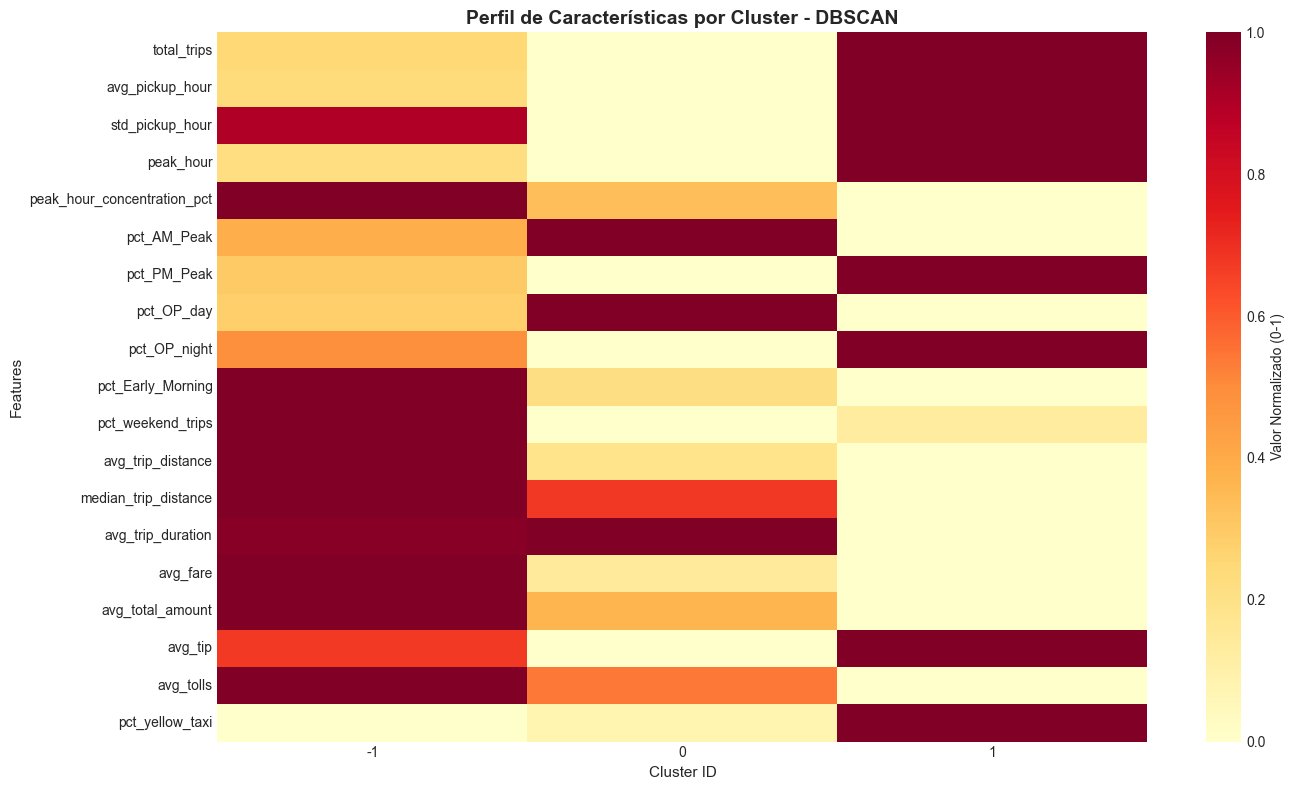

In [19]:
# Heatmap de características por cluster
fig, ax = plt.subplots(figsize=(14, 8))

# Normalizar para mejor visualización
cluster_profiles_norm = (cluster_profiles - cluster_profiles.min()) / (cluster_profiles.max() - cluster_profiles.min())

sns.heatmap(cluster_profiles_norm.T, annot=False, cmap='YlOrRd', cbar_kws={'label': 'Valor Normalizado (0-1)'})
ax.set_xlabel('Cluster ID', fontsize=11)
ax.set_ylabel('Features', fontsize=11)
ax.set_title(f'Perfil de Características por Cluster - {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# Generar insights de negocio
print("="*60)
print("INSIGHTS DE NEGOCIO POR CLUSTER")
print("="*60)

for cluster_id in sorted(zones_df['cluster'].unique()):
    if cluster_id == -1:  # Skip outliers si DBSCAN
        continue
    
    cluster_data = zones_df[zones_df['cluster'] == cluster_id]
    n_zones = len(cluster_data)
    
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_id} ({n_zones} zonas)")
    print(f"{'='*60}")
    
    # Características principales
    if 'total_trips' in cluster_data.columns:
        avg_trips = cluster_data['total_trips'].mean()
        print(f"  Viajes promedio: {avg_trips:.0f}")
    
    if 'avg_pickup_hour' in cluster_data.columns:
        avg_hour = cluster_data['avg_pickup_hour'].mean()
        print(f"  Hora pico promedio: {avg_hour:.1f}:00")
    
    if 'avg_trip_distance' in cluster_data.columns:
        avg_dist = cluster_data['avg_trip_distance'].mean()
        print(f"  Distancia promedio: {avg_dist:.2f} millas")
    
    if 'avg_fare' in cluster_data.columns:
        avg_fare = cluster_data['avg_fare'].mean()
        print(f"  Tarifa promedio: ${avg_fare:.2f}")
    
    # Clasificación de demanda
    if 'total_trips' in cluster_data.columns:
        overall_avg = zones_df['total_trips'].mean()
        if avg_trips > overall_avg * 1.5:
            classification = "🔴 ZONA DE ALTA DEMANDA"
        elif avg_trips > overall_avg:
            classification = "🟡 ZONA DE DEMANDA MEDIA-ALTA"
        elif avg_trips > overall_avg * 0.5:
            classification = "🟢 ZONA DE DEMANDA MEDIA"
        else:
            classification = "🔵 ZONA DE BAJA DEMANDA"
        
        print(f"\n  {classification}")

# Outliers de DBSCAN (si aplica)
if -1 in zones_df['cluster'].values:
    outliers = zones_df[zones_df['cluster'] == -1]
    print(f"\n{'='*60}")
    print(f"OUTLIERS/ZONAS ATÍPICAS ({len(outliers)} zonas)")
    print(f"{'='*60}")
    print("  Estas zonas tienen características únicas que no se agrupan con otras.")
    print("  Requieren estrategias de distribución personalizadas.")

INSIGHTS DE NEGOCIO POR CLUSTER

CLUSTER 0 (42 zonas)
  Viajes promedio: -0
  Hora pico promedio: -0.4:00
  Distancia promedio: -0.12 millas
  Tarifa promedio: $-0.37

  🔵 ZONA DE BAJA DEMANDA

CLUSTER 1 (41 zonas)
  Viajes promedio: 1
  Hora pico promedio: 0.7:00
  Distancia promedio: -0.16 millas
  Tarifa promedio: $-0.47

  🔴 ZONA DE ALTA DEMANDA

OUTLIERS/ZONAS ATÍPICAS (164 zonas)
  Estas zonas tienen características únicas que no se agrupan con otras.
  Requieren estrategias de distribución personalizadas.


# 11. Guardar Resultados

In [21]:
# Guardar metadata de modelos
metadata = {
    'best_model': best_model_name,
    'optimal_k': int(optimal_k),
    'metrics': {
        'kmeans': {
            'silhouette': float(kmeans_silhouette),
            'davies_bouldin': float(kmeans_davies_bouldin),
            'calinski_harabasz': float(kmeans_calinski_harabasz)
        },
        'hierarchical': {
            'silhouette': float(hierarchical_silhouette),
            'davies_bouldin': float(hierarchical_davies_bouldin),
            'calinski_harabasz': float(hierarchical_calinski_harabasz)
        }
    },
    'n_zones': int(len(zones_df)),
    'n_features': int(len(feature_cols)),
    'features': feature_cols
}

if n_clusters >= 2:
    metadata['metrics']['dbscan'] = {
        'n_clusters': int(n_clusters),
        'n_outliers': int(n_noise),
        'silhouette': float(dbscan_silhouette),
        'davies_bouldin': float(dbscan_davies_bouldin),
        'calinski_harabasz': float(dbscan_calinski_harabasz)
    }

with open('data/modeling_results.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("="*60)
print("GUARDANDO RESULTADOS")
print("="*60)
print("\nArchivos guardados:")
print("  ✓ models/feature_scaler.pkl")
print("  ✓ models/kmeans_model.pkl")
print("  ✓ models/hierarchical_model.pkl")
if n_clusters >= 2:
    print("  ✓ models/dbscan_model.pkl")
print("  ✓ data/zones_with_clusters.parquet")
print("  ✓ data/cluster_profiles.csv")
print("  ✓ data/modeling_results.json")
print("\n✓ Fase de Modelado Completada!")

GUARDANDO RESULTADOS

Archivos guardados:
  ✓ models/feature_scaler.pkl
  ✓ models/kmeans_model.pkl
  ✓ models/hierarchical_model.pkl
  ✓ models/dbscan_model.pkl
  ✓ data/zones_with_clusters.parquet
  ✓ data/cluster_profiles.csv
  ✓ data/modeling_results.json

✓ Fase de Modelado Completada!


# 12. Conclusiones y Recomendaciones

## Resumen de Resultados

- Se evaluaron **3 algoritmos de clustering**: K-Means, DBSCAN y Jerárquico
- Se identificaron clusters de zonas con patrones de demanda similares
- El mejor modelo según Silhouette Score fue seleccionado automáticamente

## Recomendaciones de Negocio

### Para Zonas de Alta Demanda (🔴)
- **Prioridad 1**: Asignar mayor número de taxis durante horas pico
- **Estrategia**: Establecer puntos de espera cercanos
- **Monitoreo**: Seguimiento en tiempo real para evitar saturación

### Para Zonas de Demanda Media (🟡🟢)
- **Prioridad 2**: Mantener disponibilidad estable
- **Estrategia**: Distribución balanceada según hora del día
- **Optimización**: Rutas eficientes entre zonas complementarias

### Para Zonas de Baja Demanda (🔵)
- **Prioridad 3**: Flota mínima necesaria
- **Estrategia**: Servicio bajo demanda o pre-agendado
- **Análisis**: Evaluar viabilidad de expansión del servicio

## Próximos Pasos

1. **Fase 5 - Evaluación**: 
   - Validar clusters con stakeholders
   - Monitorear performance en producción
   - Ajustar estrategias según feedback

2. **Implementación**:
   - Integrar modelo en sistema de dispatch
   - Dashboard de monitoreo en tiempo real
   - Alertas automáticas para zonas saturadas

3. **Mejora Continua**:
   - Re-entrenar modelos con datos actualizados mensualmente
   - Incorporar variables adicionales (clima, eventos, tráfico)
   - Modelado predictivo de demanda futura